# LightFM + CatBoost (Ranking)

In [ ]:
%pip install catboost lightfm -q

In [19]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack, eye
from lightfm import LightFM
from catboost import CatBoostRanker, Pool
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

USE_GPU = False
CATBOOST_TASK_TYPE = 'GPU' if USE_GPU else 'CPU'
print(f"CatBoost: task_type='{CATBOOST_TASK_TYPE}'")

np.random.seed(42)

CatBoost: task_type='CPU'


In [3]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv', low_memory=False)
print(f"Исходный датасет: {df.shape}")

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

for col in ['Цена']:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(str).str.replace(' ', '').str.replace(',', '.')
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

MIN_INTERACTIONS = 3
user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
before = len(df_filtered)
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(active_users) &
    df_filtered['ID_SKU'].isin(active_items)
]

print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")

Исходный датасет: (610913, 16)
Пользователей: 35,395
Товаров:       22,198
Взаимодействий:314,493


In [5]:
interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(last_date=('Дата', 'max'), count=('Дата', 'count'))
    .reset_index()
)

users = interactions['Телефон_new'].unique()
items = interactions['ID_SKU'].unique()
user2id = {u: i for i, u in enumerate(users)}
item2id = {it: i for i, it in enumerate(items)}

interactions['user_id'] = interactions['Телефон_new'].map(user2id)
interactions['item_id'] = interactions['ID_SKU'].map(item2id)

n_users = len(users)
n_items = len(items)

interactions = interactions.sort_values('last_date')
split_ts = interactions['last_date'].quantile(0.7)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions['last_date'] <  split_ts]
test_df  = interactions[interactions['last_date'] >= split_ts]

train_users = set(train_df['user_id'].unique())
test_df = test_df[test_df['user_id'].isin(train_users)]

interactions_merged = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'last_date']],
    on=['Телефон_new', 'ID_SKU']
)
train_raw = interactions_merged[interactions_merged['Дата'] < split_ts]

print(f"Train: {len(train_df):,} пар, {train_df['user_id'].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df['user_id'].nunique():,} users")

Дата разделения: 2017-04-12 17:37:00
Train: 201,147 пар, 28,017 users
Test:  42,415 пар,  7,128 users


In [6]:
def build_sparse(df, n_users, n_items):
    return csr_matrix(
        (np.ones(len(df)), (df['user_id'].values, df['item_id'].values)),
        shape=(n_users, n_items)
    )

train_matrix = build_sparse(train_df, n_users, n_items)
test_matrix  = build_sparse(test_df,  n_users, n_items)

print(f"Train matrix: {train_matrix.shape}, nnz={train_matrix.nnz:,}")
print(f"Test matrix:  {test_matrix.shape},  nnz={test_matrix.nnz:,}")

Train matrix: (35395, 22198), nnz=201,147
Test matrix:  (35395, 22198),  nnz=42,415


In [7]:
# User features
user_agg = train_raw.groupby('Телефон_new').agg(
    geo_mode=('Гео', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Регионы'),
    delivery_mode=('МетодДоставки', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
    n_orders=('НомерЗаказаНаСайте', 'nunique'),
).reset_index()

user_agg['user_id'] = user_agg['Телефон_new'].map(user2id)
user_agg = user_agg.dropna(subset=['user_id'])
user_agg['user_id'] = user_agg['user_id'].astype(int)

user_agg['price_bin'] = pd.qcut(
    user_agg['avg_price'], q=3, labels=['price_low', 'price_mid', 'price_high'], duplicates='drop'
)
user_agg['orders_bin'] = pd.qcut(
    user_agg['n_orders'].rank(method='first'), q=3,
    labels=['orders_low', 'orders_mid', 'orders_high']
)

def group_delivery(method):
    method = str(method)
    if 'Курьерская' in method: return 'delivery_courier'
    elif 'Магазины' in method or 'Самовывоз' in method: return 'delivery_store'
    else: return 'delivery_pickup'

user_agg['delivery_group'] = user_agg['delivery_mode'].apply(group_delivery)
user_agg['geo_feature'] = 'geo_' + user_agg['geo_mode'].astype(str)

user_feature_list = []
for _, row in user_agg.iterrows():
    features = [row['geo_feature'], row['delivery_group'], str(row['price_bin']), str(row['orders_bin'])]
    user_feature_list.append((int(row['user_id']), features))

all_user_features = sorted(set(f for _, feats in user_feature_list for f in feats))
print(f"Уникальных user-фичей: {len(all_user_features)}")

# Item features
item_agg = train_raw.groupby('ID_SKU').agg(
    group2_mode=('Группа2', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    group3_mode=('Группа3', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    type_mode=('Тип', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
).reset_index()

item_agg['item_id'] = item_agg['ID_SKU'].map(item2id)
item_agg = item_agg.dropna(subset=['item_id'])
item_agg['item_id'] = item_agg['item_id'].astype(int)

item_agg['item_price_bin'] = pd.qcut(
    item_agg['avg_price'], q=4,
    labels=['item_cheap', 'item_budget', 'item_mid', 'item_premium'],
    duplicates='drop'
)
item_agg['group2_feat'] = 'g2_' + item_agg['group2_mode'].astype(str)
item_agg['group3_feat'] = 'g3_' + item_agg['group3_mode'].astype(str)
item_agg['type_feat']   = 'type_' + item_agg['type_mode'].astype(str)

item_feature_list = []
for _, row in item_agg.iterrows():
    features = [row['group2_feat'], row['group3_feat'], row['type_feat'], str(row['item_price_bin'])]
    item_feature_list.append((int(row['item_id']), features))

all_item_features = sorted(set(f for _, feats in item_feature_list for f in feats))
print(f"Уникальных item-фичей: {len(all_item_features)}")

Уникальных user-фичей: 12
Уникальных item-фичей: 100


In [8]:
def build_feature_matrix(feature_list, all_features, n_entities):
    feat_to_idx = {f: i for i, f in enumerate(all_features)}
    rows, cols, data = [], [], []
    for entity_id, feats in feature_list:
        for f in feats:
            if f in feat_to_idx:
                rows.append(entity_id)
                cols.append(feat_to_idx[f])
                data.append(1.0)
    side_matrix = csr_matrix(
        (data, (rows, cols)),
        shape=(n_entities, len(all_features))
    )
    return hstack([eye(n_entities, format='csr'), side_matrix], format='csr')

user_features_matrix = build_feature_matrix(user_feature_list, all_user_features, n_users)
item_features_matrix = build_feature_matrix(item_feature_list, all_item_features, n_items)

print(f"User features: {user_features_matrix.shape}")
print(f"Item features: {item_features_matrix.shape}")

User features: (35395, 35407)
Item features: (22198, 22298)


In [ ]:
lfm_model = LightFM(
    no_components=62,
    loss='warp',
    learning_rate=0.02871393155055542,
    item_alpha=7.381847215166989e-6,
    user_alpha=5.239999784712677e-9,
    max_sampled=59,
    random_state=42
)

NUM_EPOCHS = 30
NUM_THREADS = 16

for epoch in range(NUM_EPOCHS):
    lfm_model.fit_partial(
        train_matrix,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        epochs=1,
        num_threads=NUM_THREADS
    )
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

print("LightFM обучен")


In [10]:
# Признаки пользователей
user_features_cb = train_raw.groupby('user_id').agg(
    user_n_purchases=('count', 'sum') if 'count' in train_raw.columns else ('Дата', 'count'),
    user_n_unique_items=('item_id', 'nunique'),
    user_avg_price=('Цена', 'mean'),
    user_total_margin=('Маржа', 'sum'),
    user_avg_margin=('Маржа', 'mean'),
).reset_index()

user_geo = train_raw.groupby('user_id')['Гео'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_geo.columns = ['user_id', 'user_geo']

user_delivery = train_raw.groupby('user_id')['МетодДоставки_Групп'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_delivery.columns = ['user_id', 'user_delivery_method']

user_features_cb = user_features_cb.merge(user_geo, on='user_id').merge(user_delivery, on='user_id')
print(f"User features shape: {user_features_cb.shape}")

User features shape: (28469, 8)


In [11]:
# Признаки товаров
item_features_cb = train_raw.groupby('item_id').agg(
    item_n_purchases=('Дата', 'count'),
    item_n_unique_buyers=('user_id', 'nunique'),
    item_avg_price=('Цена', 'mean'),
    item_avg_margin=('Маржа', 'mean'),
).reset_index()

item_category = train_raw.groupby('item_id')['Группа2'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
item_category.columns = ['item_id', 'item_category']

item_features_cb = item_features_cb.merge(item_category, on='item_id')
print(f"Item features shape: {item_features_cb.shape}")

Item features shape: (20745, 6)


In [12]:
test_user_items = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
eval_users = [u for u in test_user_items if u in train_users]
all_items = np.arange(n_items)

print(f"Пользователей для оценки (warm): {len(eval_users):,}")
print(f"Cold-start пользователей: {len(test_user_items) - len(eval_users):,}")

Пользователей для оценки (warm): 7,128
Cold-start пользователей: 0


In [13]:
N_CANDIDATES = 100

rows = []
for user_id in eval_users:
    scores = lfm_model.predict(
        user_id, all_items,
        user_features=user_features_matrix,
        item_features=item_features_matrix
    )
    bought = set(train_matrix[user_id].indices)
    # Убираем уже купленные, берём top-N
    candidate_scores = [(item, scores[item]) for item in range(n_items) if item not in bought]
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    candidate_scores = candidate_scores[:N_CANDIDATES]

    relevant = set(test_user_items[user_id])
    for rank, (item_id, score) in enumerate(candidate_scores):
        rows.append({
            'user_id': user_id,
            'item_id': item_id,
            'lfm_score': float(score),
            'lfm_rank': rank + 1,
            'label': int(item_id in relevant)
        })

candidates_df = pd.DataFrame(rows)
print(f"Сгенерировано кандидатов: {len(candidates_df):,}")
print(f"Доля положительных: {candidates_df['label'].mean():.4f}")

Сгенерировано кандидатов: 712,800
Доля положительных: 0.0098


In [14]:
# Присоединяем признаки
dataset = candidates_df.merge(user_features_cb, on='user_id', how='left')
dataset = dataset.merge(item_features_cb, on='item_id', how='left')

# LightFM эмбеддинги: dot, norms, cosine
user_biases, user_embeddings = lfm_model.get_user_representations(features=user_features_matrix)
item_biases, item_embeddings = lfm_model.get_item_representations(features=item_features_matrix)

u_vecs = user_embeddings[dataset['user_id'].values]
i_vecs = item_embeddings[dataset['item_id'].values]
dataset['lfm_dot'] = (u_vecs * i_vecs).sum(axis=1)
dataset['lfm_user_bias'] = user_biases[dataset['user_id'].values]
dataset['lfm_item_bias'] = item_biases[dataset['item_id'].values]
dataset['lfm_user_norm'] = np.linalg.norm(u_vecs, axis=1)
dataset['lfm_item_norm'] = np.linalg.norm(i_vecs, axis=1)
dataset['lfm_cosine'] = dataset['lfm_dot'] / (
    dataset['lfm_user_norm'] * dataset['lfm_item_norm'] + 1e-10
)

# Заполняем пропуски
num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col not in ['user_id', 'item_id', 'label']:
        dataset[col] = dataset[col].fillna(dataset[col].median())

dataset['user_geo'] = dataset['user_geo'].fillna('Неизвестно')
dataset['user_delivery_method'] = dataset['user_delivery_method'].fillna('Неизвестно')
dataset['item_category'] = dataset['item_category'].fillna('Неизвестно')

print(f"Dataset shape: {dataset.shape}")
print(f"Пропуски: {dataset.isnull().sum().sum()}")

Dataset shape: (712800, 23)
Пропуски: 0


In [15]:
all_cb_users = dataset['user_id'].unique()
np.random.seed(42)
np.random.shuffle(all_cb_users)

split_idx = int(len(all_cb_users) * 0.8)
cb_train_users = set(all_cb_users[:split_idx])
cb_val_users   = set(all_cb_users[split_idx:])

cb_train = dataset[dataset['user_id'].isin(cb_train_users)].sort_values('user_id').copy()
cb_val   = dataset[dataset['user_id'].isin(cb_val_users)].sort_values('user_id').copy()

print(f"CatBoost train: {len(cb_train):,} строк, {len(cb_train_users):,} пользователей")
print(f"CatBoost val:   {len(cb_val):,} строк, {len(cb_val_users):,} пользователей")

CatBoost train: 570,200 строк, 5,702 пользователей
CatBoost val:   142,600 строк, 1,426 пользователей


In [16]:
FEATURE_COLS = [
    'lfm_score', 'lfm_rank', 'lfm_dot', 'lfm_cosine',
    'lfm_user_bias', 'lfm_item_bias',
    'lfm_user_norm', 'lfm_item_norm',
    'user_n_purchases', 'user_n_unique_items', 'user_avg_price',
    'user_total_margin', 'user_avg_margin',
    'user_geo', 'user_delivery_method',
    'item_n_purchases', 'item_n_unique_buyers',
    'item_avg_price', 'item_avg_margin', 'item_category'
]

CAT_FEATURES = ['user_geo', 'user_delivery_method', 'item_category']

train_pool = Pool(
    data=cb_train[FEATURE_COLS],
    label=cb_train['label'],
    group_id=cb_train['user_id'],
    cat_features=CAT_FEATURES
)
val_pool = Pool(
    data=cb_val[FEATURE_COLS],
    label=cb_val['label'],
    group_id=cb_val['user_id'],
    cat_features=CAT_FEATURES
)

print(f"Features: {len(FEATURE_COLS)} (из них категориальных: {len(CAT_FEATURES)})")

Features: 20 (из них категориальных: 3)


In [20]:
cb_model = CatBoostRanker(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='YetiRank',
    eval_metric='NDCG',
    task_type=CATBOOST_TASK_TYPE,
    random_seed=42,
    verbose=50,
    early_stopping_rounds=30
)

cb_model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.7084791	best: 0.7084791 (0)	total: 267ms	remaining: 2m 13s
50:	test: 0.7455145	best: 0.7471888 (36)	total: 7.86s	remaining: 1m 9s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.747188779
bestIteration = 36

Shrink model to first 37 iterations.


CatBoostRanker(depth=6, early_stopping_rounds=30, eval_metric='NDCG', iterations=500, learning_rate=0.05, loss_function='YetiRank', random_seed=42, task_type='CPU', verbose=50)

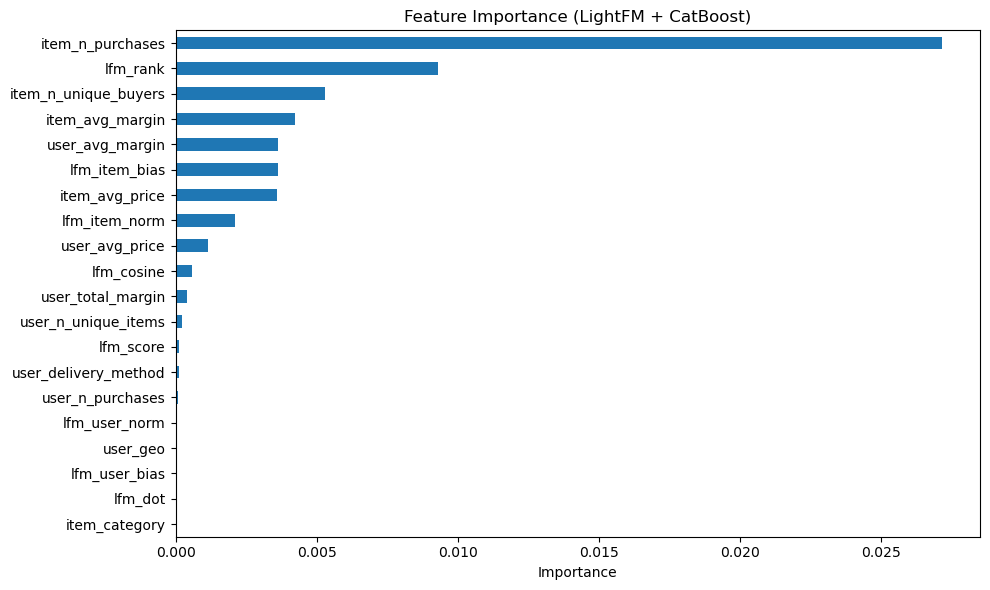

item_n_purchases        0.027134
lfm_rank                0.009301
item_n_unique_buyers    0.005289
item_avg_margin         0.004218
user_avg_margin         0.003636
lfm_item_bias           0.003612
item_avg_price          0.003583
lfm_item_norm           0.002111
user_avg_price          0.001145
lfm_cosine              0.000586
user_total_margin       0.000418
user_n_unique_items     0.000236
lfm_score               0.000128
user_delivery_method    0.000109
user_n_purchases        0.000102
lfm_user_norm           0.000054
user_geo                0.000000
lfm_user_bias           0.000000
lfm_dot                 0.000000
item_category           0.000000


In [21]:
# Важность признаков
feat_imp = pd.Series(
    cb_model.get_feature_importance(data=train_pool),
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Feature Importance (LightFM + CatBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.to_string())

In [22]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(rec_k) if rec_k else 0.0

def recall_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(set(relevant)) if relevant else 0.0

def map_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [23]:
def evaluate_hybrid(dataset_df, model, feature_cols, test_user_items, k_values=[5, 10, 20]):
    dataset_df = dataset_df.copy()
    dataset_df['cb_score'] = model.predict(dataset_df[feature_cols])

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id, group in dataset_df.groupby('user_id'):
        if user_id not in test_user_items:
            continue
        ranked = group.sort_values('cb_score', ascending=False)['item_id'].tolist()
        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(ranked, relevant, k))
            results[k]['recall'].append(recall_at_k(ranked, relevant, k))
            results[k]['map'].append(map_at_k(ranked, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(ranked, relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}


def evaluate_lfm_only(model, train_matrix, user_features_matrix, item_features_matrix,
                      test_user_items, n_items, k_values=[5, 10, 20]):
    all_items = np.arange(n_items)
    eval_users = list(test_user_items.keys())

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id in eval_users:
        scores = model.predict(
            user_id, all_items,
            user_features=user_features_matrix,
            item_features=item_features_matrix
        )
        bought = set(train_matrix[user_id].indices)
        rec = [i for i in np.argsort(-scores) if i not in bought]
        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(rec, relevant, k))
            results[k]['recall'].append(recall_at_k(rec, relevant, k))
            results[k]['map'].append(map_at_k(rec, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(rec, relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

In [24]:
k_values = [5, 10, 20]

print("Оцениваем LightFM (baseline)...")
lfm_results = evaluate_lfm_only(
    lfm_model, train_matrix, user_features_matrix, item_features_matrix,
    test_user_items, n_items, k_values
)

print("Оцениваем LightFM + CatBoost...")
hybrid_results = evaluate_hybrid(dataset, cb_model, FEATURE_COLS, test_user_items, k_values)

Оцениваем LightFM (baseline)...
Оцениваем LightFM + CatBoost...


In [25]:
print(f"{'Метрика':<20} {'LightFM':>10} {'LFM+CatBoost':>14} {'Прирост':>10}")
print("-" * 56)

for k in k_values:
    for metric in ['precision', 'recall', 'map', 'ndcg']:
        base_val   = lfm_results[k][metric]
        hybrid_val = hybrid_results[k][metric]
        delta = (hybrid_val - base_val) / (base_val + 1e-10) * 100
        sign = '+' if delta >= 0 else ''
        print(f"{metric.upper()+'@'+str(k):<20} {base_val:>10.4f} {hybrid_val:>14.4f} {sign+f'{delta:.1f}%':>10}")
    print()

Метрика                 LightFM   LFM+CatBoost    Прирост
--------------------------------------------------------
PRECISION@5              0.0214         0.0367     +71.2%
RECALL@5                 0.0261         0.0474     +81.2%
MAP@5                    0.0174         0.0352    +101.8%
NDCG@5                   0.0285         0.0529     +85.7%

PRECISION@10             0.0197         0.0304     +54.6%
RECALL@10                0.0460         0.0741     +61.0%
MAP@10                   0.0179         0.0350     +96.0%
NDCG@10                  0.0345         0.0601     +74.0%

PRECISION@20             0.0173         0.0235     +36.4%
RECALL@20                0.0783         0.1074     +37.3%
MAP@20                   0.0197         0.0367     +85.6%
NDCG@20                  0.0445         0.0699     +57.1%



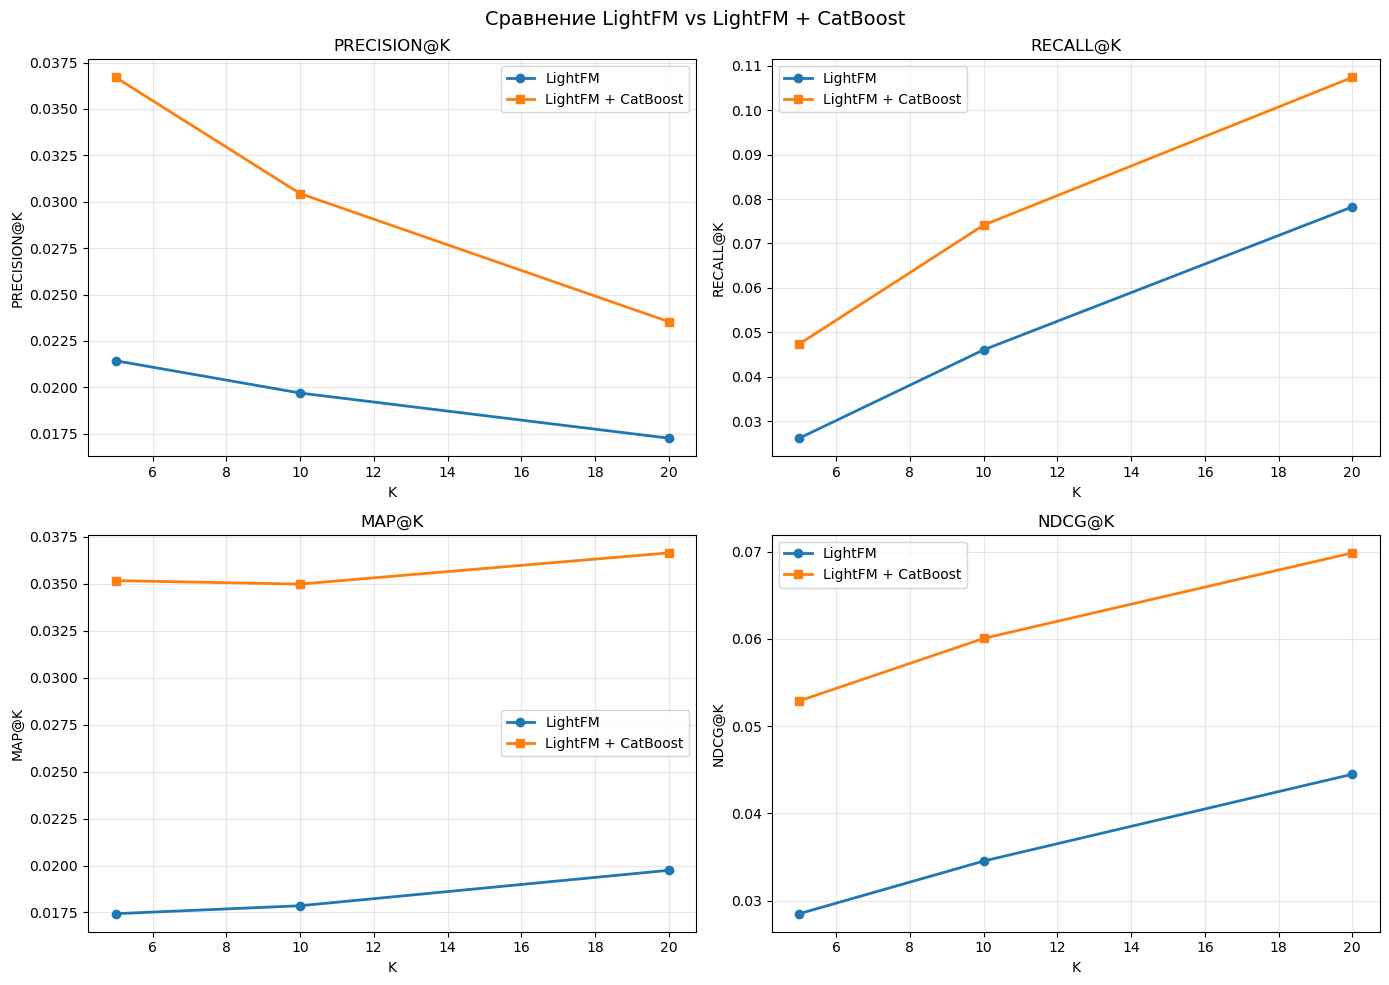

In [26]:
metrics_list = ['precision', 'recall', 'map', 'ndcg']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flat, metrics_list):
    base_vals   = [lfm_results[k][metric] for k in k_values]
    hybrid_vals = [hybrid_results[k][metric] for k in k_values]
    ax.plot(k_values, base_vals,   marker='o', label='LightFM', linewidth=2)
    ax.plot(k_values, hybrid_vals, marker='s', label='LightFM + CatBoost', linewidth=2)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение LightFM vs LightFM + CatBoost', fontsize=14)
plt.tight_layout()
plt.show()